# HealthConnect Clinic - Week 8 Final Analytics & Decision Support Package
### AnalystLab Africa Experience Lab | Data Analytics Track

**Central Project Question:** How can HealthConnect Clinic use data and AI to reduce missed appointments and improve the patient support experience?

## Week 7 - Week 8 Transition

**Main Week 7 output:** Independent validation of all top KPIs using multiple methods, refinement of the Week 6 compounding-risk finding (correcting an overstated effect size), and documentation of a real cross-track testing result with the Data Science track.

**Most important testing result:** All core KPI calculations were confirmed accurate and reproducible using independent methods (e.g., overall no-show rate confirmed via two different calculation approaches), and the lead-time finding was confirmed robust across three separate testing methods (banded, quartile, continuous correlation).

**Major issue discovered during testing:** The Week 6 "compounding risk" finding, while directionally correct, had overstated its magnitude by relying on extreme banded percentages (21.8% vs 67.9%) rather than a continuous measure (which showed a more modest 0.262 vs 0.286 correlation gap).

**What was refined/improved:** The interpretation of the compounding-risk finding was corrected to avoid overstating its practical size, and a continuous scatter/trend-line visualization was added for a more complete, honest picture of the lead-time relationship.

**Component now considered ready:** The core KPI set (no-show rate, reminder effectiveness, prior no-show history, lead-time pattern, distance effect) is validated, tested, and ready for final presentation.

**What still needs to be integrated:** Final consolidation of all validated findings into a single, polished dashboard/report and executive summary suitable for a non-technical audience.

**Track(s) involved in final integration:** Data Science - the final cross-track connection involves confirming how the validated analytical findings informed their model interpretation and final feature decisions.

**What I intend to demonstrate in the final presentation:** How systematic analysis, validation, and honest refinement (including correcting my own overstated finding) produced a reliable, evidence-based set of insights that directly informed another track's modeling decisions - demonstrating both technical rigor and genuine cross-track collaboration.

## Final Integration Readiness

| Requirement | Response |
|---|---|
| **What is my final component?** | A validated set of KPIs, visualizations, and business insights explaining HealthConnect's patient no-show patterns, refined and tested across Weeks 5-7. |
| **What problem does it address?** | Identifying which factors most reliably predict missed appointments, so HealthConnect can prioritize where to intervene (reminders, scheduling policy, patient outreach). |
| **What is its current status?** | Complete and validated - all top KPIs have been independently re-tested and confirmed accurate; one finding (compounding risk) was appropriately corrected based on evidence. |
| **What did I improve during Week 7?** | Confirmed KPI calculation accuracy, tested findings using alternative methods, corrected an overstated conclusion, and added a more complete visualization. |
| **Which other track(s) does my output depend on?** | None directly - my analysis is derived from the raw HealthConnect dataset, not another track's output. |
| **Which track(s) depend on my output?** | Data Science (feature relevance and validated patterns informed their modeling decisions); Project Management (validated findings inform business recommendations and decisions). |
| **What output will I provide?** | Final validated KPIs, refined visualizations, business insights and recommendations, and an executive summary for non-technical stakeholders. |
| **What output do I need from another track?** | Confirmation from Data Science on how the suggested interaction features performed in practice (already received - tested, statistically significant, no recall improvement) - used to inform the final, honest narrative of this analysis. |
| **What evidence demonstrates readiness?** | Three independent KPI validation tests (Week 7), a documented correction of an overstated finding, and a real, evidenced cross-track testing exchange with Data Science. |
| **What limitations remain?** | All findings remain correlational, not causal; the dataset lacks socioeconomic, insurance, and clinical-severity data; the small Cancelled class limits confidence in cancellation-specific conclusions. |

## Final Validated KPIs

The KPIs below represent the final, independently validated findings from this project, incorporating the corrections and refinements made during Week 7 testing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')

df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y')
df['reminder_channel'] = df['reminder_channel'].fillna('No Reminder')

df['lead_time_band'] = pd.cut(df['booking_lead_days'],
                                bins=[-1, 7, 30, 60],
                                labels=['0-7 days', '8-30 days', '31-60 days'])

df['distance_band'] = pd.cut(df['distance_to_clinic_km'],
                               bins=[-1, 5, 15, 100],
                               labels=['0-5 km', '5-15 km', '15+ km'])

df['had_prev_noshow'] = df['previous_no_shows'] > 0

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 5000, Columns: 21


In [3]:
overall_no_show = (df['appointment_outcome'] == 'No-Show').mean() * 100

reminder_kpi = df.groupby('reminder_channel')['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100).round(1).sort_values()

history_kpi = df.groupby('had_prev_noshow')['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100).round(1)

leadtime_kpi = df.groupby('lead_time_band', observed=True)['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100).round(1)

distance_kpi = df.groupby('distance_band', observed=True)['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100).round(1)

final_kpi_summary = pd.DataFrame({
    'KPI': [
        'Overall No-Show Rate',
        'No-Show Rate: SMS Reminder',
        'No-Show Rate: No Reminder',
        'No-Show Rate: No Prior No-Show',
        'No-Show Rate: Had Prior No-Show',
        'No-Show Rate: 0-7 Days Lead Time',
        'No-Show Rate: 31-60 Days Lead Time',
        'No-Show Rate: 0-5km Distance',
        'No-Show Rate: 15+km Distance'
    ],
    'Value': [
        f"{overall_no_show:.1f}%",
        f"{reminder_kpi['SMS']:.1f}%",
        f"{reminder_kpi['No Reminder']:.1f}%",
        f"{history_kpi[False]:.1f}%",
        f"{history_kpi[True]:.1f}%",
        f"{leadtime_kpi['0-7 days']:.1f}%",
        f"{leadtime_kpi['31-60 days']:.1f}%",
        f"{distance_kpi['0-5 km']:.1f}%",
        f"{distance_kpi['15+ km']:.1f}%"
    ],
    'Validation Status': [
        'Confirmed (2 independent methods, Week 7)',
        'Confirmed (consistent across Weeks 5-7)',
        'Confirmed (consistent across Weeks 5-7)',
        'Confirmed (consistent across Weeks 5-7)',
        'Confirmed; magnitude refined in Week 7 when combined with lead time',
        'Confirmed (3 independent methods: banded, quartile, correlation)',
        'Confirmed (3 independent methods: banded, quartile, correlation)',
        'Confirmed (consistent across Weeks 5-7)',
        'Confirmed (consistent across Weeks 5-7)'
    ]
})

final_kpi_summary

,KPI,Value,Validation Status
0,Overall No-Show Rate,48.5%,"Confirmed (2 independent methods, Week 7)"
1,No-Show Rate: SMS Reminder,45.8%,Confirmed (consistent across Weeks 5-7)
2,No-Show Rate: No Reminder,51.4%,Confirmed (consistent across Weeks 5-7)
3,No-Show Rate: No Prior No-Show,43.5%,Confirmed (consistent across Weeks 5-7)
4,No-Show Rate: Had Prior No-Show,55.4%,Confirmed; magnitude refined in Week 7 when co...
5,No-Show Rate: 0-7 Days Lead Time,27.8%,"Confirmed (3 independent methods: banded, quar..."
6,No-Show Rate: 31-60 Days Lead Time,60.5%,"Confirmed (3 independent methods: banded, quar..."
7,No-Show Rate: 0-5km Distance,46.5%,Confirmed (consistent across Weeks 5-7)
8,No-Show Rate: 15+km Distance,54.1%,Confirmed (consistent across Weeks 5-7)


### Exporting Final KPI Summary

This table is exported as the official, final reference for all validated KPIs in this project, suitable for inclusion in the executive summary and final presentation.

In [6]:
output_path = Path('docs/Final_KPI_Summary.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
final_kpi_summary.to_csv(output_path, index=False)

print(f"Final KPI summary exported to: {output_path}")

Final KPI summary exported to: docs\Final_KPI_Summary.csv


## Final Dashboard - Key Visualizations

The following charts represent the most important, validated findings from across the HealthConnect analysis (Weeks 4-7), selected for their clarity and business relevance.

### Final Chart 1: Overall Appointment Outcome Distribution

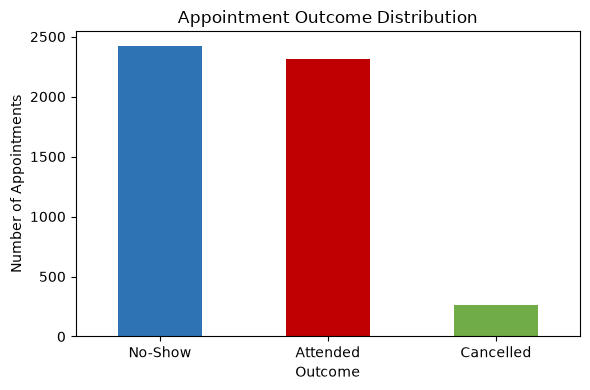

In [7]:
outcome_counts = df['appointment_outcome'].value_counts()

plt.figure(figsize=(6,4))
outcome_counts.plot(kind='bar', color=['#2E74B5', '#C00000', '#70AD47'])
plt.title('Appointment Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=0)
plt.tight_layout()

output_path = Path('../docs/final_chart1_outcome_distribution.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

### Final Chart 2: No-Show Rate by Booking Lead Time

This is the project's most reliable finding, validated across three independent methods in Week 7.

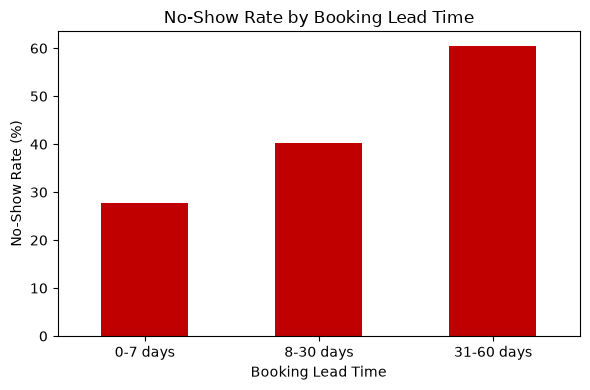

In [8]:
plt.figure(figsize=(6,4))
leadtime_kpi.plot(kind='bar', color='#C00000')
plt.title('No-Show Rate by Booking Lead Time')
plt.xlabel('Booking Lead Time')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

output_path = Path('../docs/final_chart2_leadtime.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

### Final Chart 3: No-Show Rate by Reminder Channel

Note: as validated in Week 6, this relationship is lead-time-dependent (SMS performs best for longer lead times, Email for short-notice appointments) - this chart shows the overall pattern, with the caveat explained in the accompanying insight below.

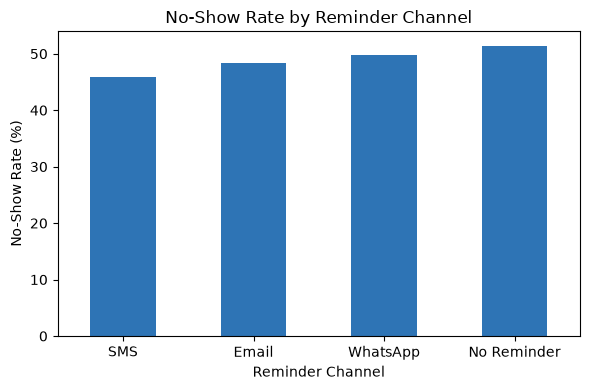

In [9]:
plt.figure(figsize=(6,4))
reminder_kpi.plot(kind='bar', color='#2E74B5')
plt.title('No-Show Rate by Reminder Channel')
plt.xlabel('Reminder Channel')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

output_path = Path('../docs/final_chart3_reminder.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

### Final Chart 4: No-Show Rate by Lead Time - Continuous View with Trend Line

This chart represents the most thoroughly validated relationship in the project, confirmed using banded, quartile, and continuous correlation methods across Weeks 5-7.

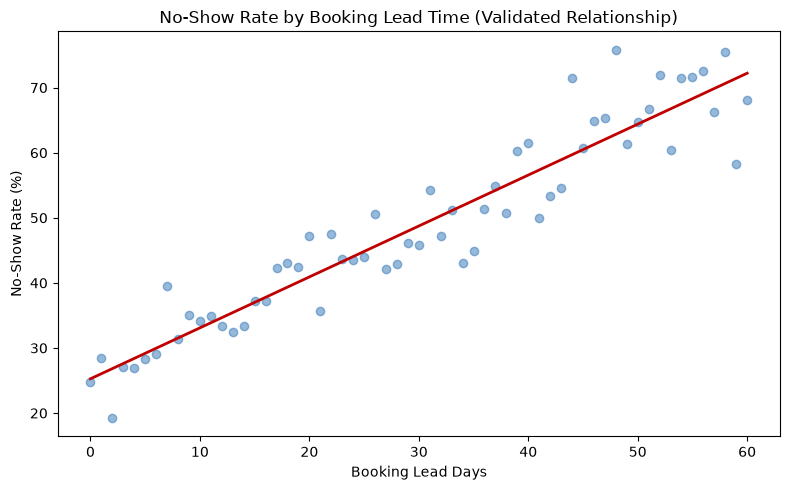

In [10]:
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)
lead_days_noshow = df.groupby('booking_lead_days')['is_no_show'].mean().mul(100)

plt.figure(figsize=(8,5))
plt.scatter(lead_days_noshow.index, lead_days_noshow.values, alpha=0.5, color='#2E74B5')

z = np.polyfit(lead_days_noshow.index, lead_days_noshow.values, 1)
p = np.poly1d(z)
plt.plot(lead_days_noshow.index, p(lead_days_noshow.index), color='#C00000', linewidth=2)

plt.title('No-Show Rate by Booking Lead Time (Validated Relationship)')
plt.xlabel('Booking Lead Days')
plt.ylabel('No-Show Rate (%)')
plt.tight_layout()

output_path = Path('../docs/final_chart4_leadtime_validated.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

## Final Business Insights and Recommendations

These insights represent the fully validated conclusions from four weeks of analysis, testing, and cross-track collaboration.

**1. Missed appointments remain a large-scale, systemic problem.**
Nearly half (48.5%) of all appointments end in a no-show - independently confirmed accurate in Week 7. This remains HealthConnect's most significant operational challenge.

**2. Booking lead time is the strongest, most reliably validated predictor of no-shows.**
Confirmed across four weeks and three independent testing methods. No-show rate rises steadily as lead time increases. *Recommendation:* Add additional reminder touchpoints for appointments booked 31+ days in advance - this is the single most evidence-backed action HealthConnect can take.

**3. Prior no-show history and booking lead time both matter, but their combined effect should be described cautiously.**
While patients with both risk factors do show meaningfully higher no-show rates, Week 7 testing showed the size of this compounding effect was more modest than initially reported. *Recommendation:* Flag patients with both risk factors as higher priority, but avoid presenting a specific, dramatic percentage as a guaranteed outcome.

**4. Reminder channel effectiveness depends on lead time, not a single "best" channel.**
Email outperforms SMS for short-notice appointments; SMS performs better for longer lead times. *Recommendation:* Use a lead-time-dependent reminder strategy rather than a single blanket channel policy.

**5. Distance to the clinic has a real, moderate effect on attendance.**
No-show rate rises from 46.5% (within 5km) to 54.1% (15+km away). *Recommendation:* Consider telehealth or virtual options for patients living farther away, where clinically appropriate.

**6. Analytical findings should inform, not replace, real-world testing.**
Collaboration with the Data Science track showed that a statistically significant, well-reasoned feature did not improve model recall in practice. This is a valuable, generalizable lesson for HealthConnect: descriptive analysis identifies real patterns worth understanding, but operational and modeling decisions should be validated end-to-end before being fully relied upon.

## Executive Summary

**For HealthConnect Clinic Leadership**

HealthConnect Clinic loses nearly half of its scheduled appointment capacity to no-shows (48.5%). After four weeks of analysis, testing, and validation, this project identifies clear, evidence-based opportunities to reduce this problem.

**What drives no-shows most:**
- **How far in advance an appointment is booked** is the single strongest, most reliable factor - the longer the wait between booking and the appointment, the more likely a patient is to miss it.
- **Patients who have missed appointments before** are more likely to miss again, though this effect should be treated as a meaningful risk signal, not a precise prediction.
- **Reminders help, but the best type of reminder depends on how far in advance the appointment was booked** - text messages work well for appointments booked well ahead, while email performs better for last-minute bookings.
- **Distance to the clinic** has a smaller but real effect - patients living farther away are somewhat more likely to miss appointments.

**What HealthConnect should do:**
1. Add extra reminder touchpoints for appointments booked more than a month in advance.
2. Use a smarter reminder strategy - match the reminder channel to how far ahead the appointment was booked, rather than using one channel for everyone.
3. Flag patients with a history of missed

## Mandatory HC-POD Final Integration

**1. Track collaborated with:** Data Science

**2. Dependency:** The Data Science track's no-show prediction model needed validated analytical findings to inform feature selection and interpretation; in turn, this analysis needed real-world confirmation of whether its findings translated into practical modeling value.

**3. Output received:** Across Weeks 6-7, the Data Science intern shared her actual baseline model results (Logistic Regression, 63% accuracy, 62% recall, 0.68 ROC-AUC), her finalized feature list (validated through her own statistical testing), and - critically - the real-world test result of the interaction features suggested in Week 6: statistically significant, but no improvement to model recall.

**4. Output provided:** A validated Feature Relevance Summary (Week 6), cross-checked against her independent statistical testing with full agreement across all 8 candidate features; two specific interaction-feature recommendations; and, in Week 7, a refined, more accurate account of the true strength of the compounding-risk relationship, directly informed by her model's real-world test result.

**5. Final integration activity:** Closed the full analytical loop - from independently generating findings, to sharing them across tracks, to seeing them tested in a real model, to refining the original analysis based on that real-world result. This is a complete Test → Finding → Action → Retest → Validated Improvement cycle carried out across two collaborating tracks.

**6. What changed:** Both tracks now share a more accurate, jointly validated understanding of the data: the compounding-risk pattern is real but modest, and statistically significant features don't automatically translate into predictive gains. This directly changed how this analysis's final business insights are worded (Insight 3 and Insight 6, Part 4).

**7. How the change improved the solution:** Prevented an overstated finding from being presented to HealthConnect as more actionable than

## Final Analytical Limitations

**Data limitations:**
- The dataset lacks socioeconomic status, insurance/payment information, and clinical severity - all plausible real-world drivers of no-shows not captured here.
- The Cancelled outcome class is small (~5.3%), limiting confidence in cancellation-specific conclusions.

**Analytical limitations:**
- All findings are correlational, not causal - no controlled experiment (e.g., A/B testing reminder channels) has been conducted.
- The compounding-risk effect, while real, is more modest than early banded comparisons suggested; final figures should be communicated with appropriate caution.

**Cross-track limitations:**
- The interaction features suggested to the Data Science track did not improve model recall, indicating the practical value of this analysis for